In [8]:
import pandas as pd
import requests
import json
from datetime import datetime, timedelta

In [16]:
import time

from tqdm import tqdm


API = "https://en.wikipedia.org/w/api.php"
HEADERS = {"User-Agent": "WikiResearchBot/0.1 (t.j.wies@gmail.com)"}

def get_template_links(template_title: str) -> list[str]:
    params = {
        "action": "query",
        "format": "json",
        "prop": "links",
        "titles": template_title,
        "pllimit": "max",
        "plnamespace": 0,   # main/article namespace only
        "formatversion": 2,
    }

    titles = []
    while True:
        resp = requests.get(API, params=params, headers=HEADERS, timeout=20)
        resp.raise_for_status()
        data = resp.json()

        pages = data.get("query", {}).get("pages", [])
        if pages:
            links = pages[0].get("links", [])
            titles.extend(link["title"] for link in links)

        if "continue" in data:
            params.update(data["continue"])
        else:
            break

    return sorted(set(titles))

def get_revision_diff(parent_id, rev_id):
    params = {
        "action": "compare",
        "format": "json",
        "fromrev": parent_id,
        "torev": rev_id,
        "prop": "diff|ids|title",
        "formatversion": "2",
    }

    resp = requests.get(API, params=params, headers=HEADERS, timeout=10)
    resp.raise_for_status()
    data = resp.json()

    compare = data.get("compare", {})
    return compare.get("*") or compare.get("body") or compare.get("diff")


def get_revisions(page_title, talk=False, include_diff=False, sleep_sec=0.0):
    if talk and not page_title.startswith("Talk:"):
        page_title = "Talk:" + page_title

    params = {
        "action": "query",
        "format": "json",
        "prop": "revisions",
        "titles": page_title,
        "rvprop": "ids|timestamp|user|comment|size",
        "rvlimit": "max",
        "formatversion": "2",
    }

    all_revisions = []

    while True:
        resp = requests.get(API, params=params, headers=HEADERS, timeout=10)
        resp.raise_for_status()
        data = resp.json()

        pages = data.get("query", {}).get("pages", [])
        if pages and "revisions" in pages[0]:
            all_revisions.extend(pages[0]["revisions"])

        if "continue" in data:
            params.update(data["continue"])
        else:
            break

    df = pd.DataFrame(all_revisions)

    if df.empty:
        return df

    df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True)
    df["page_title"] = page_title

    if include_diff:
        diffs = []
        for _, row in df.iterrows():
            rev_id = row.get("revid")
            parent_id = row.get("parentid")

            if pd.isna(rev_id) or pd.isna(parent_id) or parent_id == 0:
                diffs.append(None)
            else:
                try:
                    diff_html = get_revision_diff(int(parent_id), int(rev_id))
                    diffs.append(diff_html)
                    if sleep_sec > 0:
                        time.sleep(sleep_sec)
                except Exception:
                    diffs.append(None)

        df["diff_html"] = diffs

    df["comment"] = df["comment"].fillna("")
    df["comment_len"] = df["comment"].str.len()
    df["has_reply"] = df["comment"].str.contains("Reply", case=False, regex=False).astype(int)
    df["has_revert"] = df["comment"].str.contains("revert", case=False, regex=True).astype(int)
    df["size_change"] = df["size"].diff().abs()

    return df

def format_revisions(revisions):

    if revisions is None:
        return pd.DataFrame()
    if revisions.empty:
        return revisions
    df = revisions
    df["timestamp"] = pd.to_datetime(df["timestamp"])
    df = df.sort_values("timestamp")
    df["timestamp"] = df["timestamp"].dt.floor("h")
    print(df.head())
    edits = df.groupby("timestamp").size().rename("edits")
    unique_editors = df.groupby("timestamp")["user"].nunique().rename("unique_editors")

    df["seen_before"] = df["user"].duplicated()
    df["new_editor"] = (~df["seen_before"]).astype(int)
    new_editors = df.groupby("timestamp")["new_editor"].sum().rename("new_editors")
    total_comment_len = df.groupby("timestamp")["comment_len"].sum().rename("total_comment_len")
    num_replies = df.groupby("timestamp")["has_reply"].sum().rename("num_replies")
    num_reverts = df.groupby("timestamp")["has_revert"].sum().rename("num_reverts")
    features = pd.concat([edits, unique_editors, new_editors, total_comment_len, num_replies, num_reverts], axis=1).fillna(0)

    return features.reset_index().sort_values("timestamp")

In [17]:
titles = get_template_links("Template:Campaignbox 2026 Iran war")
from tqdm import tqdm
all_revisions = []
features = pd.DataFrame()
for i in tqdm(titles):
    rev = get_revisions(i, talk=False, include_diff=False, sleep_sec=0)
    talk_rev = get_revisions(i, talk=True, include_diff=False, sleep_sec=0)

    if not rev.empty:
        all_revisions.append(rev)
    if not talk_rev.empty:
        all_revisions.append(talk_rev)

    
all_revisions = pd.concat(all_revisions)
all_revisions["seen_before_global"] = all_revisions["user"].duplicated()
all_revisions["new_editor_global"] = (~all_revisions["seen_before_global"]).astype(int)

# clean + sort
all_revisions["timestamp"] = pd.to_datetime(all_revisions["timestamp"], utc=True)
all_revisions = all_revisions.sort_values("timestamp")

revisions = format_revisions(all_revisions)

# GLOBAL new editors (across ALL pages)
all_revisions["seen_before_global"] = all_revisions["user"].duplicated()
all_revisions["new_editor_global"] = (~all_revisions["seen_before_global"]).astype(int)

# comment features
all_revisions["comment"] = all_revisions["comment"].fillna("")
all_revisions["comment_len"] = all_revisions["comment"].str.len()
all_revisions["has_reply"] = all_revisions["comment"].str.contains("Reply", case=False).astype(int)
all_revisions["has_revert"] = all_revisions["comment"].str.contains("revert", case=False).astype(int)

# size change (global ordering matters here too)
all_revisions["size_change"] = all_revisions["size"].diff().abs()

# floor timestamps to hour
all_revisions["timestamp"] = all_revisions["timestamp"].dt.floor("h")

features = all_revisions.groupby("timestamp").agg(
    edits=("user", "count"),
    unique_editors=("user", "nunique"),
    new_editors=("new_editor_global", "sum"),
    total_comment_len=("comment_len", "sum"),
    num_replies=("has_reply", "sum"),
    num_reverts=("has_revert", "sum"),
).reset_index().sort_values("timestamp")

100%|██████████| 107/107 [00:49<00:00,  2.16it/s]


       revid  parentid           user                 timestamp  size  \
537  1346952         0  134.76.145.47 2003-08-26 06:00:00+00:00   180   
536  1346983   1346952  134.76.145.47 2003-08-26 06:00:00+00:00   198   
84   1346999         0      Lypheklub 2003-08-26 06:00:00+00:00   145   
535  1352877   1346983      Lypheklub 2003-08-26 06:00:00+00:00   197   
83   4789297   1346999    Loren Rosen 2003-08-26 06:00:00+00:00   304   

                          comment  anon             page_title  comment_len  \
537                                True       War profiteering            0   
536                                True       War profiteering            0   
84   motion to move to Wiktionary   NaN  Talk:War profiteering           28   
535                                 NaN       War profiteering            0   
83                                  NaN  Talk:War profiteering            0   

     has_reply  has_revert  size_change temp commenthidden userhidden  \
537          

In [11]:
import json
from datetime import datetime, timedelta, timezone
import pandas as pd
import requests

GAMMA = "https://gamma-api.polymarket.com"
CLOB = "https://clob.polymarket.com"

HEADERS = {
    "User-Agent": "research-script/0.1 (you@example.com)"
}

def _maybe_json_load(value):
    if isinstance(value, str):
        try:
            return json.loads(value)
        except json.JSONDecodeError:
            return value
    return value

def fetch_event_by_slug(slug: str, headers: dict | None = None) -> dict:
    headers = headers or HEADERS
    resp = requests.get(
        f"{GAMMA}/events",
        params={"slug": slug},
        headers=headers,
        timeout=20,
    )
    resp.raise_for_status()
    data = resp.json()

    if isinstance(data, list):
        if not data:
            raise ValueError(f"No event found for slug '{slug}'")
        return data[0]

    if not data:
        raise ValueError(f"No event found for slug '{slug}'")

    return data

def extract_market_tokens(event: dict) -> list[dict]:
    rows = []

    for market in event.get("markets", []):
        outcomes = _maybe_json_load(market.get("outcomes"))
        clob_ids = _maybe_json_load(market.get("clobTokenIds"))

        if not outcomes or not clob_ids:
            continue
        if len(outcomes) != len(clob_ids):
            continue

        token_map = dict(zip(outcomes, clob_ids))
        rows.append(
            {
                "market_question": market.get("question"),
                "market_slug": market.get("slug"),
                "token_map": token_map,
            }
        )

    if not rows:
        raise ValueError("No markets with token IDs found in event.")

    return rows

def get_yes_token_from_event(event: dict, market_question_contains: str | None = None) -> tuple[str, str]:
    markets = extract_market_tokens(event)

    if market_question_contains:
        needle = market_question_contains.lower()
        markets = [
            m for m in markets
            if needle in (m["market_question"] or "").lower()
        ]
        if not markets:
            raise ValueError(
                f"No market question matched substring: {market_question_contains!r}"
            )

    for m in markets:
        token_map = m["token_map"]
        if "Yes" in token_map:
            return token_map["Yes"], m["market_question"]

    raise ValueError("No 'Yes' token found in selected markets.")

def fetch_price_history_window(
    token_id: str,
    start_ts: int,
    end_ts: int,
    interval: str = "1h",
    fidelity: int = 60,
    headers: dict | None = None,
) -> pd.DataFrame:
    headers = headers or HEADERS

    resp = requests.get(
        f"{CLOB}/prices-history",
        params={
            "market": token_id,
            "startTs": start_ts,
            "endTs": end_ts,
            "interval": interval,
            "fidelity": fidelity,
        },
        headers=headers,
        timeout=20,
    )
    resp.raise_for_status()
    data = resp.json()

    history = data.get("history", [])
    df = pd.DataFrame(history)

    if df.empty:
        return df

    df["timestamp"] = pd.to_datetime(df["t"], unit="s", utc=True)
    df = df.rename(columns={"p": "price"}).sort_values("timestamp")
    return df[["timestamp", "price"]]

def fetch_price_history_paginated(
    token_id: str,
    days: int = 30,
    chunk_days: int = 7,
    interval: str = "1h",
    fidelity: int = 60,
    headers: dict | None = None,
) -> pd.DataFrame:
    headers = headers or HEADERS

    end_dt = datetime.now(timezone.utc)
    start_dt = end_dt - timedelta(days=days)

    all_chunks = []
    chunk_end = end_dt

    while chunk_end > start_dt:
        chunk_start = max(start_dt, chunk_end - timedelta(days=chunk_days))

        df_chunk = fetch_price_history_window(
            token_id=token_id,
            start_ts=int(chunk_start.timestamp()),
            end_ts=int(chunk_end.timestamp()),
            interval=interval,
            fidelity=fidelity,
            headers=headers,
        )

        if not df_chunk.empty:
            all_chunks.append(df_chunk)

        # move window backward
        chunk_end = chunk_start

    if not all_chunks:
        return pd.DataFrame(columns=["timestamp", "price"])

    out = (
        pd.concat(all_chunks, ignore_index=True)
        .drop_duplicates(subset="timestamp")
        .sort_values("timestamp")
        .reset_index(drop=True)
    )
    return out

def get_price_series_from_slug(
    slug: str,
    days: int = 30,
    chunk_days: int = 7,
    interval: str = "1h",
    fidelity: int = 60,
    market_question_contains: str | None = None,
    headers: dict | None = None,
) -> tuple[pd.DataFrame, dict]:
    headers = headers or HEADERS

    event = fetch_event_by_slug(slug, headers=headers)
    token_id, market_question = get_yes_token_from_event(
        event,
        market_question_contains=market_question_contains,
    )

    df = fetch_price_history_paginated(
        token_id=token_id,
        days=days,
        chunk_days=chunk_days,
        interval=interval,
        fidelity=fidelity,
        headers=headers,
    )

    meta = {
        "event_title": event.get("title"),
        "event_slug": event.get("slug"),
        "market_question": market_question,
        "yes_token_id": token_id,
    }

    return df, meta

# Example usage
slug = "will-the-us-invade-iran-before-2027"

prices, meta = get_price_series_from_slug(
    slug=slug,
    days=30,
    chunk_days=7,
    interval="1h",
    fidelity=60,
)

print(meta)
print(prices.head())
print(prices.tail())
print(f"Rows returned: {len(prices)}")

{'event_title': 'Will the U.S. invade Iran before 2027?', 'event_slug': 'will-the-us-invade-iran-before-2027', 'market_question': 'Will the U.S. invade Iran before 2027?', 'yes_token_id': '55115078421062885512539156303747803058407616201213034911037320915726138659123'}
                  timestamp  price
0 2026-03-24 18:00:24+00:00  0.595
1 2026-03-24 19:00:21+00:00  0.590
2 2026-03-24 20:00:24+00:00  0.585
3 2026-03-24 21:00:22+00:00  0.540
4 2026-03-24 22:00:19+00:00  0.540
                    timestamp  price
673 2026-04-23 14:00:05+00:00  0.305
674 2026-04-23 15:00:04+00:00  0.305
675 2026-04-23 16:00:04+00:00  0.305
676 2026-04-23 17:00:04+00:00  0.305
677 2026-04-23 17:18:06+00:00  0.315
Rows returned: 678


In [12]:
# --- BASIC CHECKS ---
print("Rows:", len(prices))
print("Time range:", prices["timestamp"].min(), "→", prices["timestamp"].max())

# --- SORT + CLEAN ---
prices = prices.sort_values("timestamp").drop_duplicates("timestamp")

# --- CHECK FOR GAPS ---
prices["delta"] = prices["timestamp"].diff()

print("\nUnique time deltas:")
print(prices["delta"].value_counts().head())

# --- EXPECTED FREQUENCY CHECK (1h) ---
expected = pd.Timedelta("1h")
gaps = prices[prices["delta"] > expected]

print(f"\nNumber of gaps > 1h: {len(gaps)}")

if len(gaps) > 0:
    print("\nExample gaps:")
    print(gaps[["timestamp", "delta"]].head())

# --- CHECK FOR DUPLICATES ---
dupes = prices["timestamp"].duplicated().sum()
print("\nDuplicate timestamps:", dupes)

# --- RESAMPLE TO CLEAN GRID ---
prices_clean = (
    prices.set_index("timestamp")
    .resample("1h")
    .last()   # 👈 use last observed price
    .ffill()
    .reset_index()
)

print("\nAfter resampling:")
print("Rows:", len(prices_clean))

# --- FINAL SANITY ---
print("\nFinal time delta check:")
print(prices_clean["timestamp"].diff().value_counts().head())

Rows: 678
Time range: 2026-03-24 18:00:24+00:00 → 2026-04-23 17:18:06+00:00

Unique time deltas:
delta
0 days 01:00:00    84
0 days 01:00:01    57
0 days 00:59:59    50
0 days 01:00:02    40
0 days 00:59:58    37
Name: count, dtype: int64

Number of gaps > 1h: 326

Example gaps:
                   timestamp           delta
2  2026-03-24 20:00:24+00:00 0 days 01:00:03
5  2026-03-24 23:00:24+00:00 0 days 01:00:05
8  2026-03-25 02:00:24+00:00 0 days 01:00:02
10 2026-03-25 04:00:25+00:00 0 days 01:00:05
15 2026-03-25 09:00:22+00:00 0 days 01:00:01

Duplicate timestamps: 0

After resampling:
Rows: 720

Final time delta check:
timestamp
0 days 01:00:00    719
Name: count, dtype: int64


In [13]:
features.head()

,timestamp,edits,unique_editors,new_editors,total_comment_len,num_replies,num_reverts
0,2003-08-26 06:00:00+00:00,5,3,3,28,0,0
1,2003-08-27 14:00:00+00:00,2,2,1,13,0,0
2,2003-08-27 16:00:00+00:00,2,1,0,0,0,0
3,2003-09-03 04:00:00+00:00,1,1,1,36,0,0
4,2003-11-22 00:00:00+00:00,1,1,1,26,0,0


In [24]:
prices_hourly = (
    prices.set_index("timestamp")
    .resample("1h")
    .mean()
    .ffill()
    .reset_index()
)

features_hourly = (
    features.set_index("timestamp")
    .resample("1h")
    .sum()
    .fillna(0)
    .reset_index()
)

df = pd.merge_asof(
    prices_hourly.sort_values("timestamp"),
    features_hourly.sort_values("timestamp"),
    on="timestamp",
    direction="backward"
)

df["timestamp"] = pd.to_datetime(df["timestamp"])
df = df.sort_values("timestamp").set_index("timestamp")
windows = ["30min", "1h", "3h", "6h", "12h", "24h"]

for w in windows:
    df[f"edits_{w}"] = df["edits"].rolling(w).mean()
    df[f"edits_{w}_diff"] = df[f"edits_{w}"].diff()
    df[f"delta_price_{w}"] = df["price"].shift(-int(w[0])) - df["price"]
    df[f"abs_delta_price_move_{w}"] = df[f"delta_price_{w}"].abs()
    df[f"unique_editors_{w}"] = df["unique_editors"].rolling(w).mean()
    df[f"new_editors_{w}"] = df["new_editors"].rolling(w).mean()
    df[f"total_comment_len_{w}"] = df['total_comment_len'].rolling(w).mean()
    df[f"num_replies_{w}"] = df['num_replies'].rolling(w).mean()
    df[f"num_reverts_{w}"] = df['num_reverts'].rolling(w).mean()
    df["returns"] = df["price"].pct_change()
    df[f"volatility_{w}"] = df["returns"].rolling(w).std()
# edits at time t predicting future
for i in range(1, 25):
    df[f"edits_lag_{i}"] = df[f"edits_1h_diff"].shift(i)
    df[f"new_editors_lag_{i}"] = df[f"new_editors_1h"].shift(i)
    df[f"unique_editors_lag_{i}"] = df["unique_editors_1h"].shift(i)
    df[f"total_comment_len_lag_{i}"] = df["total_comment_len_1h"].shift(i)
    df[f"num_replies_lag_{i}"] = df["num_replies_1h"].shift(i)
    df[f"num_reverts_lag_{i}"] = df['num_reverts_1h'].shift(i)

/var/folders/1r/k6vlr74j5_j3ftfp83kg694m0000gn/T/ipykernel_6869/1893568018.py:42: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"edits_lag_{i}"] = df[f"edits_1h_diff"].shift(i)
/var/folders/1r/k6vlr74j5_j3ftfp83kg694m0000gn/T/ipykernel_6869/1893568018.py:43: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"new_editors_lag_{i}"] = df[f"new_editors_1h"].shift(i)
/var/folders/1r/k6vlr74j5_j3ftfp83kg694m0000gn/T/ipykernel_6869/1893568018.py:44: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of 

In [25]:
df.shape

(720, 213)

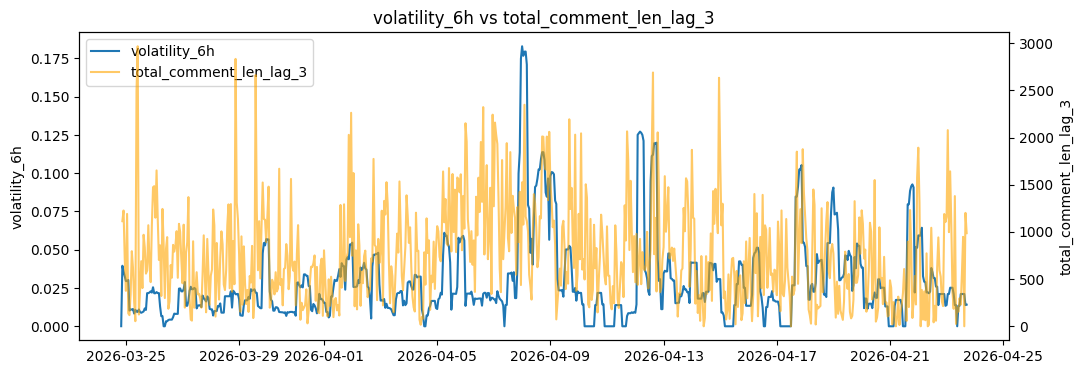

In [32]:
import matplotlib.pyplot as plt

def plot_rolling_delta(col1: str, col2: str):
    fig, ax1 = plt.subplots(figsize=(12,4))
    ax1.plot(df.index, df[col1], label=col1)
    ax1.set_ylabel(col1)

    ax2 = ax1.twinx()
    ax2.plot(df.index, df[col2], color="orange", alpha=0.6, label=col2)
    ax2.set_ylabel(col2)

    # Combine legends from both axes
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

    plt.title(f"{col1} vs {col2}")
    plt.show()


plot_rolling_delta("volatility_6h", "total_comment_len_lag_3")

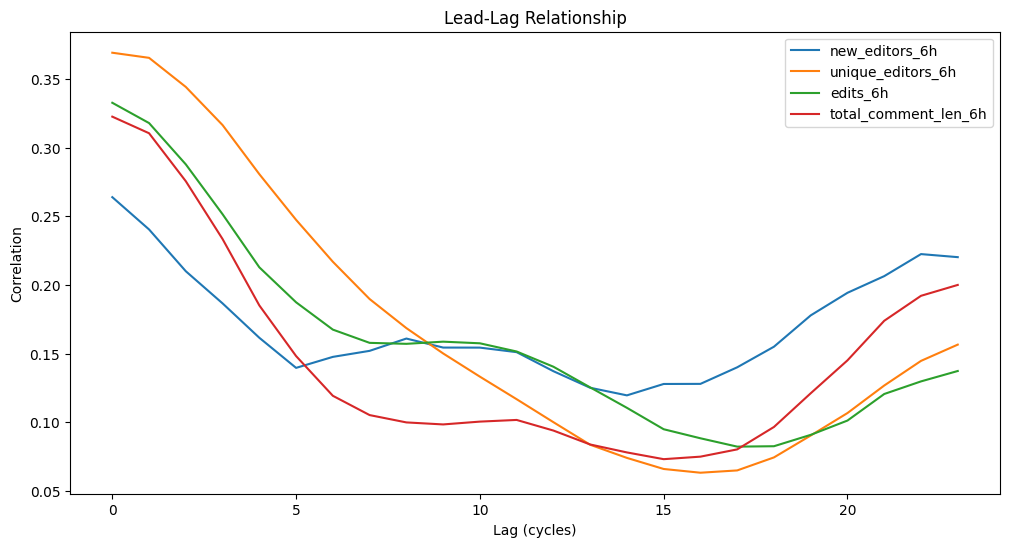

In [29]:
corrs = []
df["target"] = df["volatility_6h"].shift(-1)
for lag in range(0, 24):
    shifted = df["new_editors_6h"].shift(lag)
    corr = shifted.corr(df["target"])
    corrs.append(corr)

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(range(24), corrs, label="new_editors_6h")

for col in ["unique_editors_6h", "edits_6h", "total_comment_len_6h"]:
    corrs_col = []
    for lag in range(0, 24):
        shifted = df[col].shift(lag)
        corr = shifted.corr(df["target"])
        corrs_col.append(corr)
    plt.plot(range(24), corrs_col, label=col)

plt.legend()
plt.xlabel("Lag (cycles)")
plt.ylabel("Correlation")
plt.title("Lead-Lag Relationship")
plt.show()

In [54]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import roc_auc_score

# optional: defragment after lots of earlier column creation
df = df.copy()

# target: future absolute move
df["target"] = df["target"] = df["volatility_6h"].shift(-1)

# feature engineering
bases = ["total_comment_len", "edits", "new_editors", "unique_editors"]

new_cols = {}
for base in bases:
    short = df[f"{base}_lag_1"]
    medium = df[f"{base}_lag_12"]
    long = df[f"{base}_lag_24"]

    new_cols[f"{base}_short"] = short
    new_cols[f"{base}_medium"] = medium
    new_cols[f"{base}_long"] = long
    new_cols[f"{base}_accel"] = short - medium
    new_cols[f"{base}_decay"] = medium - long

df = pd.concat([df, pd.DataFrame(new_cols, index=df.index)], axis=1).copy()

selected_features = [
    "unique_editors_short",
    "total_comment_len_short",
    "new_editors_short",
    "edits_short",
    "new_editors_accel",
]

# build clean frame WITHOUT big_move yet
model_df = pd.concat([df[selected_features], df["target"]], axis=1).dropna().copy()

# chronological split
split = int(len(model_df) * 0.7)
train_df = model_df.iloc[:split].copy()
test_df = model_df.iloc[split:].copy()

# threshold from TRAIN ONLY
threshold = train_df["target"].quantile(0.8)

train_df["big_move"] = (train_df["target"] > threshold).astype(int)
test_df["big_move"] = (test_df["target"] > threshold).astype(int)

print("Train class counts:")
print(train_df["big_move"].value_counts())
print("\nTest class counts:")
print(test_df["big_move"].value_counts())

# fail early if still only one class
if train_df["big_move"].nunique() < 2:
    raise ValueError(
        "Training set still has only one class. "
        "Try a lower threshold (e.g. 0.7), a longer window, or more data."
    )

X_train = train_df[selected_features]
X_test = test_df[selected_features]
y_train = train_df["big_move"]
y_test = test_df["big_move"]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

y_pred_prob = model.predict_proba(X_test_scaled)[:, 1]
auc = roc_auc_score(y_test, y_pred_prob)

print("\nAUC:", auc)

Train class counts:
big_move
0    395
1     99
Name: count, dtype: int64

Test class counts:
big_move
0    154
1     59
Name: count, dtype: int64

AUC: 0.5676865507373983


In [55]:
y_train_shuffled = y_train.sample(frac=1, random_state=42)

model.fit(X_train_scaled, y_train_shuffled)
y_pred_prob_shuffled = model.predict_proba(X_test_scaled)[:, 1]

print("Shuffled AUC:", roc_auc_score(y_test, y_pred_prob_shuffled))

Shuffled AUC: 0.5192604006163328
